# Import libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Set the Dataset folder path

In [2]:
# The notebook is inside the Notebook folder
data_dir = Path("../Dataset")

# Fallback if VS Code starts from the project root
if not data_dir.exists():
    data_dir = Path("Dataset")

print("Dataset folder:", data_dir.resolve())

Dataset folder: /home/yoke/Market-Basket-Analysis/Dataset


# Load all six CSV files

In [4]:
aisles = pd.read_csv(data_dir / "aisles.csv")
departments = pd.read_csv(data_dir / "departments.csv")
orders = pd.read_csv(data_dir / "orders.csv")
products = pd.read_csv(data_dir / "products.csv")

order_products_prior = pd.read_csv(
    data_dir / "order_products__prior.csv"
)

order_products_train = pd.read_csv(
    data_dir / "order_products__train.csv"
)

# Check all loaded tables

In [5]:
tables = {
    "aisles": aisles,
    "departments": departments,
    "orders": orders,
    "products": products,
    "order_products_prior": order_products_prior,
    "order_products_train": order_products_train
}

for table_name, df in tables.items():
    print(f"{table_name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

aisles: 134 rows × 2 columns
departments: 21 rows × 2 columns
orders: 3,421,083 rows × 7 columns
products: 49,688 rows × 4 columns
order_products_prior: 32,434,489 rows × 4 columns
order_products_train: 1,384,617 rows × 4 columns


# Preview one table

In [6]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [8]:
products.head()


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [9]:
aisles.head()


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [10]:
departments.head()


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [11]:
order_products_prior.head()


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [12]:
order_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


# View the first five rows

In [13]:
for table_name, df in tables.items():
    print(f"\n===== {table_name.upper()} =====")
    display(df.head())


===== AISLES =====


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



===== DEPARTMENTS =====


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol



===== ORDERS =====


...

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



===== ORDER_PRODUCTS_PRIOR =====


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0



===== ORDER_PRODUCTS_TRAIN =====


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


# Check rows and columns

In [14]:
shape_summary = pd.DataFrame({
    table_name: {
        "Rows": df.shape[0],
        "Columns": df.shape[1]
    }
    for table_name, df in tables.items()
}).T

shape_summary


,Rows,Columns
aisles,134,2
departments,21,2
orders,3421083,7
products,49688,4
order_products_prior,32434489,4
order_products_train,1384617,4


# Check column information

In [22]:
print("Missing values in aisles.csv")
aisles.isnull().sum()

Missing values in aisles.csv


aisle_id    0
aisle       0
dtype: int64

In [23]:
print("Missing values in departments.csv")
departments.isnull().sum()


Missing values in departments.csv


department_id    0
department       0
dtype: int64

In [24]:
print("Missing values in orders.csv")
orders.isnull().sum()

Missing values in orders.csv


order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

In [25]:
print("Missing values in products.csv")
products.isnull().sum()

Missing values in products.csv


product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

In [26]:
print("Missing values in order_products__prior.csv")
order_products_prior.isnull().sum()

Missing values in order_products__prior.csv


order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [27]:
print("Missing values in order_products__train.csv")
order_products_train.isnull().sum()

Missing values in order_products__train.csv


order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

In [28]:
missing = aisles.isnull().sum()

pd.DataFrame({
    "Column": aisles.columns,
    "Data Type": aisles.dtypes.astype(str).values,
    "Total Rows": len(aisles),
    "Non-Null Values": len(aisles) - missing.values,
    "Missing Values": missing.values,
    "Missing (%)": (missing.values / len(aisles) * 100).round(2)
})

,Column,Data Type,Total Rows,Non-Null Values,Missing Values,Missing (%)
0,aisle_id,int64,134,134,0,0.0
1,aisle,object,134,134,0,0.0


In [29]:
missing = departments.isnull().sum()

pd.DataFrame({
    "Column": departments.columns,
    "Data Type": departments.dtypes.astype(str).values,
    "Total Rows": len(departments),
    "Non-Null Values": len(departments) - missing.values,
    "Missing Values": missing.values,
    "Missing (%)": (missing.values / len(departments) * 100).round(2)
})

,Column,Data Type,Total Rows,Non-Null Values,Missing Values,Missing (%)
0,department_id,int64,21,21,0,0.0
1,department,object,21,21,0,0.0


In [30]:
missing = orders.isnull().sum()

pd.DataFrame({
    "Column": orders.columns,
    "Data Type": orders.dtypes.astype(str).values,
    "Total Rows": len(orders),
    "Non-Null Values": len(orders) - missing.values,
    "Missing Values": missing.values,
    "Missing (%)": (missing.values / len(orders) * 100).round(2)
})

,Column,Data Type,Total Rows,Non-Null Values,Missing Values,Missing (%)
0,order_id,int64,3421083,3421083,0,0.00
1,user_id,int64,3421083,3421083,0,0.00
2,eval_set,object,3421083,3421083,0,0.00
3,order_number,int64,3421083,3421083,0,0.00
4,order_dow,int64,3421083,3421083,0,0.00
5,order_hour_of_day,int64,3421083,3421083,0,0.00
6,days_since_prior_order,float64,3421083,3214874,206209,6.03


In [31]:
missing = products.isnull().sum()

pd.DataFrame({
    "Column": products.columns,
    "Data Type": products.dtypes.astype(str).values,
    "Total Rows": len(products),
    "Non-Null Values": len(products) - missing.values,
    "Missing Values": missing.values,
    "Missing (%)": (missing.values / len(products) * 100).round(2)
})

,Column,Data Type,Total Rows,Non-Null Values,Missing Values,Missing (%)
0,product_id,int64,49688,49688,0,0.0
1,product_name,object,49688,49688,0,0.0
2,aisle_id,int64,49688,49688,0,0.0
3,department_id,int64,49688,49688,0,0.0


In [32]:
missing = order_products_prior.isnull().sum()

pd.DataFrame({
    "Column": order_products_prior.columns,
    "Data Type": order_products_prior.dtypes.astype(str).values,
    "Total Rows": len(order_products_prior),
    "Non-Null Values": len(order_products_prior) - missing.values,
    "Missing Values": missing.values,
    "Missing (%)": (
        missing.values / len(order_products_prior) * 100
    ).round(2)
})

,Column,Data Type,Total Rows,Non-Null Values,Missing Values,Missing (%)
0,order_id,int64,32434489,32434489,0,0.0
1,product_id,int64,32434489,32434489,0,0.0
2,add_to_cart_order,int64,32434489,32434489,0,0.0
3,reordered,int64,32434489,32434489,0,0.0


In [33]:
missing = order_products_train.isnull().sum()

pd.DataFrame({
    "Column": order_products_train.columns,
    "Data Type": order_products_train.dtypes.astype(str).values,
    "Total Rows": len(order_products_train),
    "Non-Null Values": len(order_products_train) - missing.values,
    "Missing Values": missing.values,
    "Missing (%)": (
        missing.values / len(order_products_train) * 100
    ).round(2)
})

,Column,Data Type,Total Rows,Non-Null Values,Missing Values,Missing (%)
0,order_id,int64,1384617,1384617,0,0.0
1,product_id,int64,1384617,1384617,0,0.0
2,add_to_cart_order,int64,1384617,1384617,0,0.0
3,reordered,int64,1384617,1384617,0,0.0


In [35]:
print("Description of aisles.csv")
display(aisles.describe(include="all").T)

Description of aisles.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
aisle_id,134.0,NaN,NaN,NaN,67.5,38.826537,1.0,34.25,67.5,100.75,134.0
aisle,134,134,prepared soups salads,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
print("Description of departments.csv")
display(departments.describe(include="all").T)

Description of departments.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
department_id,21.0,NaN,NaN,NaN,11.0,6.204837,1.0,6.0,11.0,16.0,21.0
department,21,21,frozen,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
print("Description of orders.csv")
display(orders.describe(include="all").T)

Description of orders.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,3421083.0,NaN,NaN,NaN,1710542.0,987581.739825,1.0,855271.5,1710542.0,2565812.5,3421083.0
user_id,3421083.0,NaN,NaN,NaN,102978.208059,59533.717793,1.0,51394.0,102689.0,154385.0,206209.0
eval_set,3421083,3,prior,3214874,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_number,3421083.0,NaN,NaN,NaN,17.154858,17.733164,1.0,5.0,11.0,23.0,100.0
order_dow,3421083.0,NaN,NaN,NaN,2.776219,2.046829,0.0,1.0,3.0,5.0,6.0
order_hour_of_day,3421083.0,NaN,NaN,NaN,13.452015,4.226088,0.0,10.0,13.0,16.0,23.0
days_since_prior_order,3214874.0,NaN,NaN,NaN,11.114836,9.206737,0.0,4.0,7.0,15.0,30.0


In [38]:
print("Description of products.csv")
display(products.describe(include="all").T)

Description of products.csv


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,49688.0,NaN,NaN,NaN,24844.5,14343.834425,1.0,12422.75,24844.5,37266.25,49688.0
product_name,49688,49688,Chocolate Sandwich Cookies,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
aisle_id,49688.0,NaN,NaN,NaN,67.769582,38.316162,1.0,35.0,69.0,100.0,134.0
department_id,49688.0,NaN,NaN,NaN,11.728687,5.85041,1.0,7.0,13.0,17.0,21.0


In [39]:
print("Description of order_products__prior.csv")
display(order_products_prior.describe(include="all").T)

Description of order_products__prior.csv


,count,mean,std,min,25%,50%,75%,max
order_id,32434489.0,1.710749e+06,987300.696453,2.0,855943.0,1711048.0,2565514.0,3421083.0
product_id,32434489.0,2.557634e+04,14096.689090,1.0,13530.0,25256.0,37935.0,49688.0
add_to_cart_order,32434489.0,8.351076e+00,7.126671,1.0,3.0,6.0,11.0,145.0
reordered,32434489.0,5.896975e-01,0.491889,0.0,0.0,1.0,1.0,1.0


In [40]:
print("Description of order_products__train.csv")
display(order_products_train.describe(include="all").T)

Description of order_products__train.csv


,count,mean,std,min,25%,50%,75%,max
order_id,1384617.0,1.706298e+06,989732.648868,1.0,843370.0,1701880.0,2568023.0,3421070.0
product_id,1384617.0,2.555624e+04,14121.272449,1.0,13380.0,25298.0,37940.0,49688.0
add_to_cart_order,1384617.0,8.758044e+00,7.423936,1.0,3.0,7.0,12.0,80.0
reordered,1384617.0,5.985944e-01,0.490183,0.0,0.0,1.0,1.0,1.0


In [41]:
print("Exact duplicate rows:", aisles.duplicated().sum())
print(
    "Duplicate aisle_id:",
    aisles.duplicated(subset=["aisle_id"]).sum()
)

Exact duplicate rows: 0
Duplicate aisle_id: 0


In [42]:
print("Exact duplicate rows:", departments.duplicated().sum())
print(
    "Duplicate department_id:",
    departments.duplicated(subset=["department_id"]).sum()
)

Exact duplicate rows: 0
Duplicate department_id: 0


In [44]:
print("Exact duplicate rows:", orders.duplicated().sum())
print(
    "Duplicate order_id:",
    orders.duplicated(subset=["order_id"]).sum()
)

Exact duplicate rows: 0
Duplicate order_id: 0


In [45]:
print("Exact duplicate rows:", products.duplicated().sum())
print(
    "Duplicate product_id:",
    products.duplicated(subset=["product_id"]).sum()
)

Exact duplicate rows: 0
Duplicate product_id: 0


In [46]:
print(
    "Exact duplicate rows:",
    order_products_prior.duplicated().sum()
)

print(
    "Duplicate order-product combinations:",
    order_products_prior.duplicated(
        subset=["order_id", "product_id"]
    ).sum()
)

Exact duplicate rows: 0
Duplicate order-product combinations: 0


In [47]:
print(
    "Exact duplicate rows:",
    order_products_train.duplicated().sum()
)

print(
    "Duplicate order-product combinations:",
    order_products_train.duplicated(
        subset=["order_id", "product_id"]
    ).sum()
)

Exact duplicate rows: 0
Duplicate order-product combinations: 0


### Blank values in days_since_prior_order were converted to numeric NaN. These values represent customers’ first orders, where no previous-order interval exists. They were retained to preserve valid records and avoid incorrectly interpreting them as zero-day reorders.

In [48]:
orders["days_since_prior_order"] = pd.to_numeric(
    orders["days_since_prior_order"],
    errors="coerce"
)

# Check Outlier

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### orders.csv — order_number

Lower limit: -22.0
Upper limit: 50.0
Number of outliers: 216870


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
364,933179,27,prior,51,2,9,5.0
365,682914,27,prior,52,3,15,15.0
366,1149184,27,prior,53,2,9,6.0
367,65724,27,prior,54,4,15,2.0
368,2244394,27,prior,55,2,16,5.0
...,...,...,...,...,...,...,...
3420997,2643521,206206,prior,64,0,17,2.0
3420998,2750895,206206,prior,65,3,14,10.0
3420999,2986341,206206,prior,66,3,9,14.0
3421000,1904200,206206,prior,67,0,13,11.0


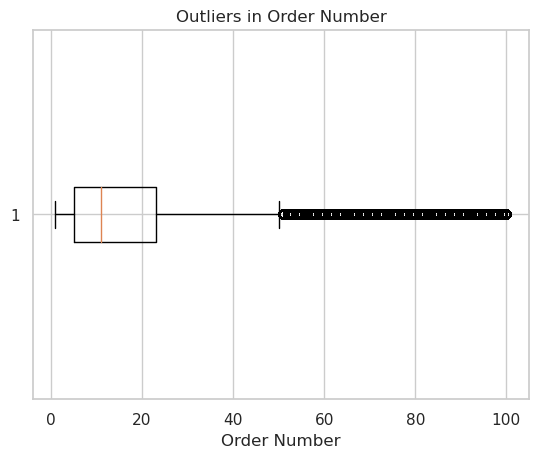

In [59]:
Q1 = orders["order_number"].quantile(0.25)
Q3 = orders["order_number"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

order_number_outliers = orders[
    (orders["order_number"] < lower) |
    (orders["order_number"] > upper)
]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(order_number_outliers))

display(order_number_outliers)

plt.boxplot(orders["order_number"], vert=False)
plt.title("Outliers in Order Number")
plt.xlabel("Order Number")
plt.show()

### orders.csv — days_since_prior_order

Lower limit: -12.5
Upper limit: 31.5
Number of outliers: 0


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order


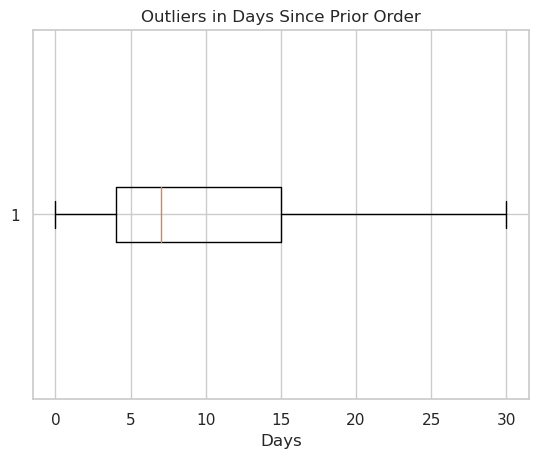

In [60]:
days = orders["days_since_prior_order"].dropna()

Q1 = days.quantile(0.25)
Q3 = days.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

days_outliers = orders[
    (orders["days_since_prior_order"] < lower) |
    (orders["days_since_prior_order"] > upper)
]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(days_outliers))

display(days_outliers)

plt.boxplot(days, vert=False)
plt.title("Outliers in Days Since Prior Order")
plt.xlabel("Days")
plt.show()

### order_products__prior.csv — add_to_cart_order

Number of outliers: 1357124


,order_id,product_id,add_to_cart_order,reordered
53,5,38693,24,0
54,5,48825,25,0
55,5,8479,26,0
167,18,35547,24,1
168,18,33279,25,0
...,...,...,...,...
32434270,3421051,8277,27,1
32434271,3421051,20549,28,1
32434272,3421051,19678,29,0
32434273,3421051,48775,30,1


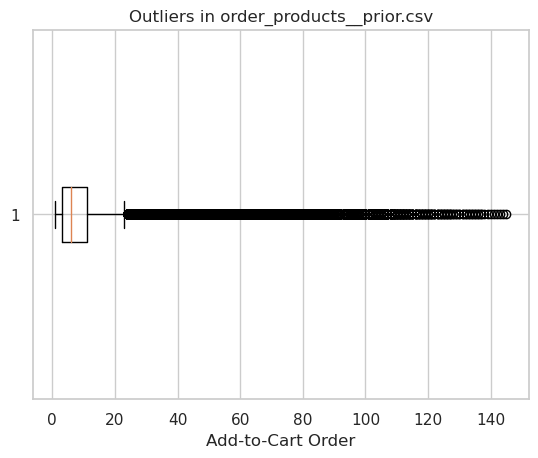

In [63]:
cart = order_products_prior["add_to_cart_order"]

Q1 = cart.quantile(0.25)
Q3 = cart.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

prior_outliers = order_products_prior[
    (cart < lower) | (cart > upper)
]

print("Number of outliers:", len(prior_outliers))
display(prior_outliers)

plt.boxplot(cart, vert=False)
plt.title("Outliers in order_products__prior.csv")
plt.xlabel("Add-to-Cart Order")
plt.show()

### order_products__train.csv  — add_to_cart_order

Number of outliers: 50853


,order_id,product_id,add_to_cart_order,reordered
57,98,47333,26,1
58,98,48287,27,1
59,98,45204,28,1
60,98,24964,29,1
61,98,18117,30,1
...,...,...,...,...
1384281,3420286,16759,35,0
1384282,3420286,22935,36,1
1384582,3420998,41950,26,0
1384583,3420998,8174,27,0


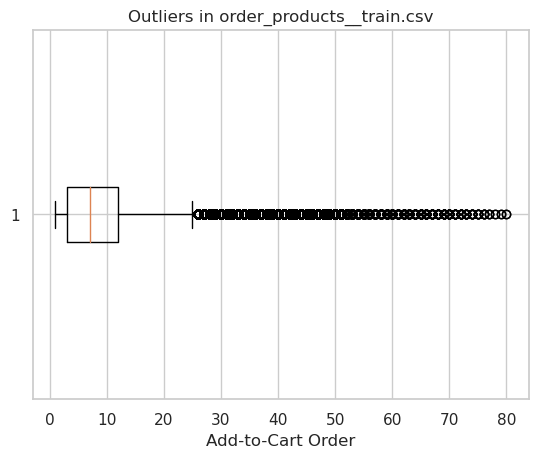

In [64]:
cart = order_products_train["add_to_cart_order"]

Q1 = cart.quantile(0.25)
Q3 = cart.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

train_outliers = order_products_train[
    (cart < lower) | (cart > upper)
]

print("Number of outliers:", len(train_outliers))
display(train_outliers)

plt.boxplot(cart, vert=False)
plt.title("Outliers in order_products__train.csv")
plt.xlabel("Add-to-Cart Order")
plt.show()

### three graphs show potential IQR outliers. They are the circles beyond the right whisker.

### Variable	Outlier rule	Count	Interpretation
### order_number	Above 50	216,870	Frequent customers with many orders
### Prior add_to_cart_order	Above 23	1,357,124	Products in large baskets
### Train add_to_cart_order	26 or above	50,853	Products in large baskets

### These are unusual values, but not data errors. Keep them because frequent customers and large baskets are useful for market-basket and cross-selling analysis. Do not remove them automatically.

In [65]:
print(len(order_number_outliers))
print(len(prior_outliers))
print(len(train_outliers))

216870
1357124
50853


### aisles, departments, and products contain identifiers/categories, so IQR outlier detection is not meaningful.
### orders passed all valid-range checks.
### order_products__prior: 1,357,124 potential outliers (4.18%), with cart positions above 23.
### order_products__train: 50,853 potential outliers (3.67%), with cart positions above 25.5.
### These are probably valid large shopping baskets, so they should not be automatically removed.


In [66]:
final_file = data_dir / "orders_cleaned.csv"

orders.to_csv(
    final_file,
    index=False,
    na_rep="NaN"
)

print("Saved:", final_file)

Saved: ../Dataset/orders_cleaned.csv
